In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [77]:
# Make the corner plot for the MCMC results
system_name = 'J1251'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [78]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,3.313828,264.3945,1.134566,-0.339567,0.488696,-17.11826
1,3.683635,264.4343,1.133802,-0.340222,0.488670,-17.19676
2,5.387140,264.6898,1.130450,-0.340440,0.486721,-17.19539
3,6.213405,264.7544,1.128618,-0.335704,0.473770,-17.23095
4,5.825451,264.2562,1.125739,-0.334594,0.469021,-17.26306
...,...,...,...,...,...,...
2147,9.445751,264.3331,1.157526,-0.345426,0.525308,-17.43094
2148,12.630920,264.4337,1.159040,-0.340641,0.528448,-17.43413
2149,11.472920,264.5919,1.159542,-0.344694,0.522623,-17.32444
2150,9.576424,264.5012,1.158496,-0.340892,0.527513,-17.23079


In [79]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [75]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

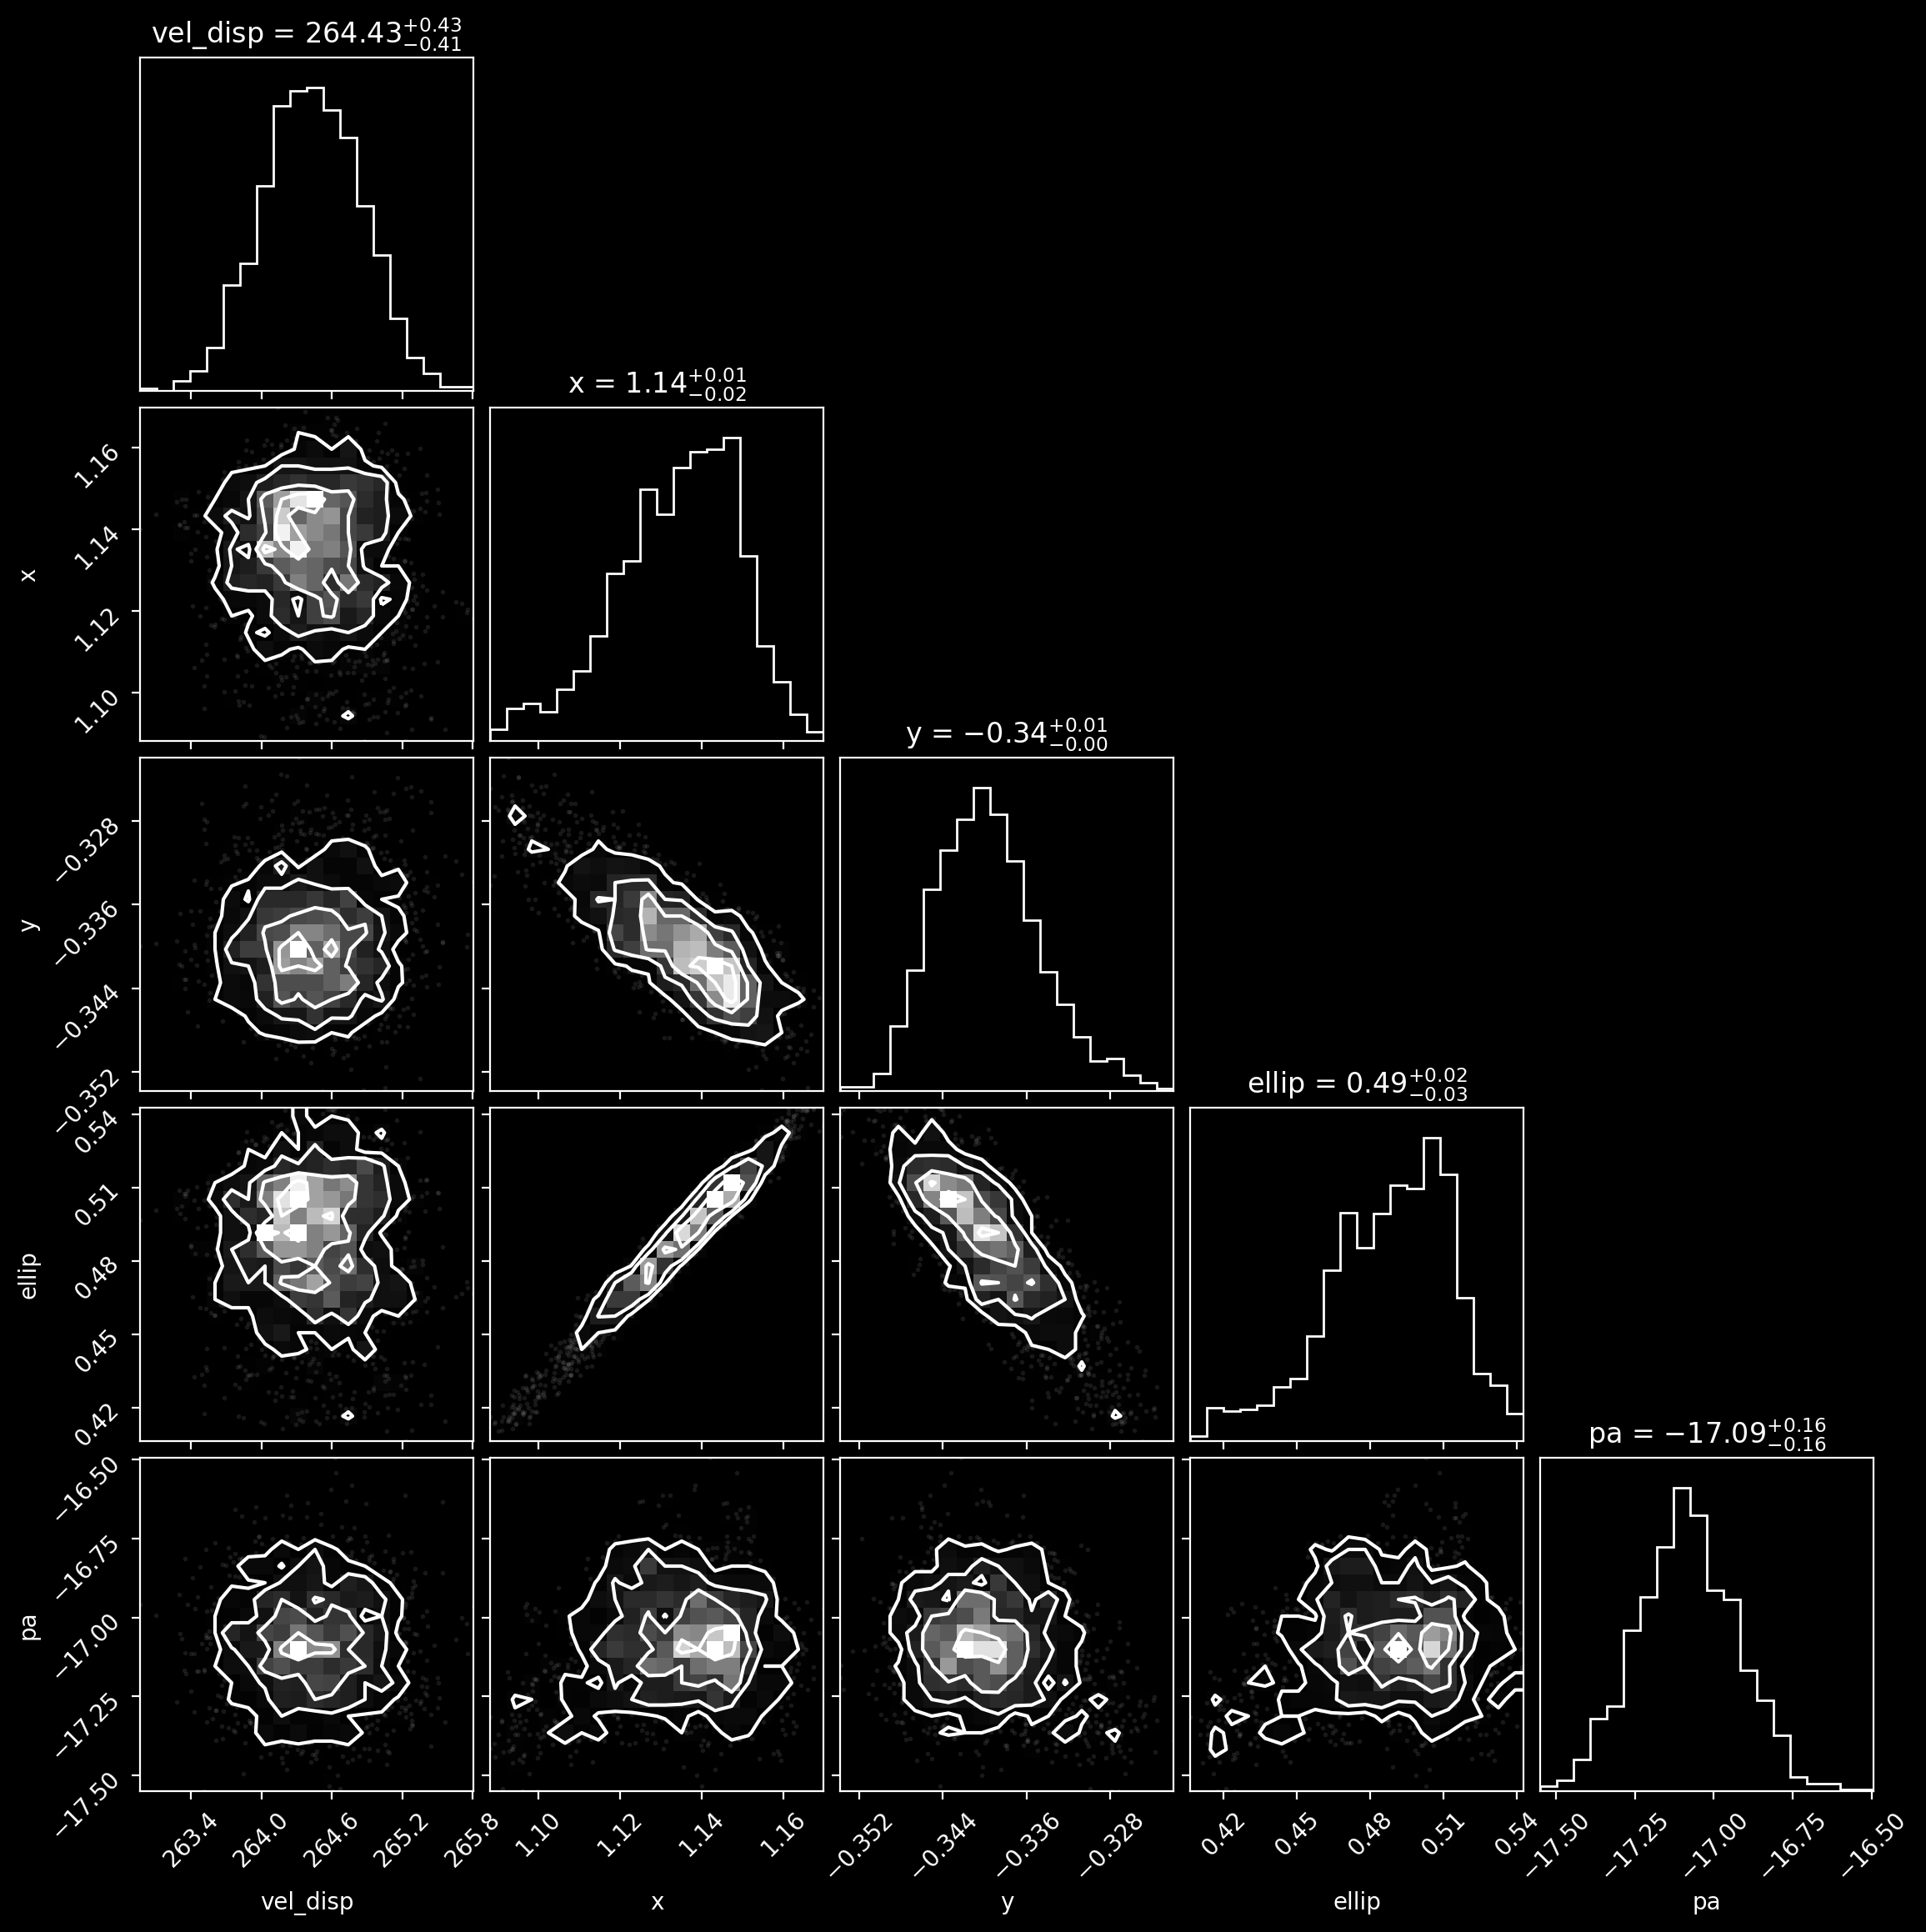

In [80]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')